## Equipo 48 - Nombres y Matriculas:

| ID         | Name                             |
|------------|----------------------------------|
| A01796245  | Oscar Luis Guadarrama Jiménez    |
| A01795463  | Luis Alejandro Juárez Rodríguez  |
| A01795188  | José Manuel Pérez González       |



# 🔬 EDA — Metales Pesados en Unidades Bovinas Lecheras
### Municipio de Lerma de Villada, Estado de México

**Estudio descriptivo:** Al, As, Cd, Cr, Cu, Pb, Zn en matrices: Agua, Forraje, Pelo y Leche  
**Metodología:** Digestión HClO₄/H₂SO₄ + Lectura ICP-OES Varian 725-ES  
**Referencia:** Reyes-Garcilazo et al. — Congreso Chapingo

---

## 0. Configuración e importaciones

In [25]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

# ── Rutas ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
BASE_PATH = PROJECT_ROOT / 'data' / 'raw' / 'csv'
OUT_PATH  = PROJECT_ROOT / 'data' / 'processed' / 'eda_outputs'
OUT_PATH.mkdir(parents=True, exist_ok=True)
# Cada archivo tiene un número distinto de filas de encabezado a saltar
# Leche/Pelo/Forraje: fila 0-3 = meta, fila 4 = header real
# Agua: fila 0-2 = meta, fila 3 = header real
FILES = {
    'Leche':   (BASE_PATH / '2734_2825_LECHE_B&S%201-4.csv',  4),
    'Pelo':    (BASE_PATH / '256_295_PELO_B&S%201.csv',        4),
    'Forraje': (BASE_PATH / '236_255_FORRAJE_B&S%201.csv',     4),
    'Agua':    (BASE_PATH / '216_235_AGUAS_B&S%201.csv',       3),
}

# Límites Máximos de Residuos (LMR) — del artículo de referencia
LMR = {'Al': 1.00, 'As': 0.20, 'Cd': 0.50, 'Cr': 0.05, 'Cu': 0.01, 'Pb': 1.00, 'Zn': 0.30}

COLORES = {'Leche': '#4C9BE8', 'Pelo': '#E87B4C', 'Forraje': '#5CB85C', 'Agua': '#9B59B6'}
print(FILES)
print('✅ Configuración lista')

{'Leche': (PosixPath('/home/jperez/ml-nutraceuticos-ganado-lechero/data/raw/csv/2734_2825_LECHE_B&S%201-4.csv'), 4), 'Pelo': (PosixPath('/home/jperez/ml-nutraceuticos-ganado-lechero/data/raw/csv/256_295_PELO_B&S%201.csv'), 4), 'Forraje': (PosixPath('/home/jperez/ml-nutraceuticos-ganado-lechero/data/raw/csv/236_255_FORRAJE_B&S%201.csv'), 4), 'Agua': (PosixPath('/home/jperez/ml-nutraceuticos-ganado-lechero/data/raw/csv/216_235_AGUAS_B&S%201.csv'), 3)}
✅ Configuración lista


## 1. Carga y limpieza de datos

In [26]:
def cargar_df(path, header_row, nombre_matriz):
    """Lee el CSV respetando las filas de meta-info superiores."""
    df = pd.read_csv(path, header=header_row)
    
    # Eliminar filas que sean totalmente NaN (pie de tabla)
    df = df.dropna(how='all').reset_index(drop=True)
    
    # Columnas de metales: las que contienen 'ppm'
    cols_metal = [c for c in df.columns if 'ppm' in str(c).lower()]
    
    # Columna de lugar
    lugar_col = next((c for c in df.columns if 'lugar' in str(c).lower()), None)
    if lugar_col and lugar_col != 'Lugar':
        df = df.rename(columns={lugar_col: 'Lugar'})
    
    # Convertir metales: 'nd' / 'ND' / '-' → NaN, luego float
    for col in cols_metal:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.strip()
                   .replace({'nd': np.nan, 'ND': np.nan, '-': np.nan, 'nan': np.nan, 'None': np.nan}),
            errors='coerce'
        )
    
    df['Matriz'] = nombre_matriz
    return df, cols_metal


dataframes    = {}
metales_por   = {}   # {nombre: [col_names_originales]}

for nombre, (path, hrow) in FILES.items():
    df, cols = cargar_df(path, hrow, nombre)
    dataframes[nombre] = df
    metales_por[nombre] = cols
    print(f'📂 {nombre:10s}  →  {df.shape[0]:3d} filas | metales: {[c.strip() for c in cols]}')

print(f'\n✅ Total muestras: {sum(d.shape[0] for d in dataframes.values())}')

📂 Leche       →   90 filas | metales: ['Al  ppm', 'As  ppm', 'Cd  ppm', 'Cr  ppm', 'Cu  ppm', 'Pb  ppm', 'Zn  ppm']
📂 Pelo        →   40 filas | metales: ['Al  ppm', 'As  ppm', 'Cd  ppm', 'Cr  ppm', 'Cu  ppm', 'Pb  ppm', 'Zn  ppm']
📂 Forraje     →   20 filas | metales: ['Al  ppm', 'As  ppm', 'Cd  ppm', 'Cr  ppm', 'Cu  ppm', 'Pb  ppm', 'Zn  ppm']
📂 Agua        →   18 filas | metales: ['Al  ppm', 'As  ppm', 'Cd  ppm', 'Cr  ppm', 'Cu  ppm', 'Pb  ppm', 'Zn  ppm']

✅ Total muestras: 168


In [27]:
# ── Dataset unificado ────────────────────────────────────────────────────
def nombre_corto(col):
    """'Al  ppm' → 'Al'"""
    return col.replace('ppm', '').replace('  ', ' ').strip()

METALES_COLS = ['Al', 'As', 'Cd', 'Cr', 'Cu', 'Pb', 'Zn']

dfs_std = []
for nombre, df in dataframes.items():
    mapa  = {c: nombre_corto(c) for c in metales_por[nombre]}
    df_s  = df.rename(columns=mapa)
    cols_keep = ['Lugar', 'Matriz'] + [m for m in METALES_COLS if m in df_s.columns]
    dfs_std.append(df_s[cols_keep])

df_all = pd.concat(dfs_std, ignore_index=True)

print(f'Dataset combinado: {df_all.shape}')
df_all.head(8)

Dataset combinado: (168, 9)


,Lugar,Matriz,Al,As,Cd,Cr,Cu,Pb,Zn
0,San Mateo 3,Leche,2.307,2.118,NaN,1.228,1.253,3.116,0.806
1,NaN,Leche,NaN,0.473,NaN,0.479,0.387,0.591,NaN
2,NaN,Leche,NaN,4.742,NaN,0.643,0.515,0.100,NaN
3,NaN,Leche,NaN,3.523,NaN,0.466,0.237,0.608,NaN
4,NaN,Leche,NaN,3.508,NaN,0.500,0.160,2.362,NaN
5,NaN,Leche,NaN,1.355,NaN,0.285,0.232,1.416,NaN
6,NaN,Leche,NaN,1.583,NaN,0.542,0.210,1.175,NaN
7,NaN,Leche,NaN,2.315,NaN,0.472,0.241,1.156,NaN


## 2. Estadísticas descriptivas por matriz

In [28]:
for nombre, df in dataframes.items():
    mapa  = {c: nombre_corto(c) for c in metales_por[nombre]}
    df_m  = df[metales_por[nombre]].rename(columns=mapa)
    
    print(f'\n{"="*60}')
    print(f'  📊 MATRIZ: {nombre.upper()}  (n={len(df_m)})')
    print(f'{"="*60}')
    print(df_m.describe().round(4).to_string())
    
    nd_pct = df_m.isna().mean().mul(100).round(1)
    print(f'\n  % No Detectado (ND):')
    print(nd_pct.to_string())
    
    print(f'\n  Distribución por Lugar:')
    print(df['Lugar'].value_counts().to_string())


  📊 MATRIZ: LECHE  (n=90)
             Al       As      Cd       Cr       Cu       Pb     Zn
count   12.0000  81.0000  2.0000  90.0000  88.0000  68.0000  1.000
mean    26.4643   2.4100  0.0115   1.3341   0.3970   1.2319  0.806
std     33.8571   1.4948  0.0078   2.4345   0.4174   0.9983    NaN
min      0.7840   0.1500  0.0060   0.2460   0.0310   0.0160  0.806
25%      2.0270   1.3550  0.0088   0.5580   0.2328   0.6312  0.806
50%     22.2855   2.0600  0.0115   1.1005   0.3050   1.0970  0.806
75%     34.3755   3.0950  0.0142   1.4925   0.3895   1.6825  0.806
max    121.6490   7.0300  0.0170  23.5570   3.0810   6.6850  0.806

  % No Detectado (ND):
Al    86.7
As    10.0
Cd    97.8
Cr     0.0
Cu     2.2
Pb    24.4
Zn    98.9

  Distribución por Lugar:
Lugar
San Mateo 3                   1
Lerma 3                       1
Lerma 2                       1
Lerma 1                       1
Ocoyoacac 1                   1
San Mateo 2                   1
San Mateo 1                   1
San Agustín 

## 3. Análisis de valores No Detectados (ND)

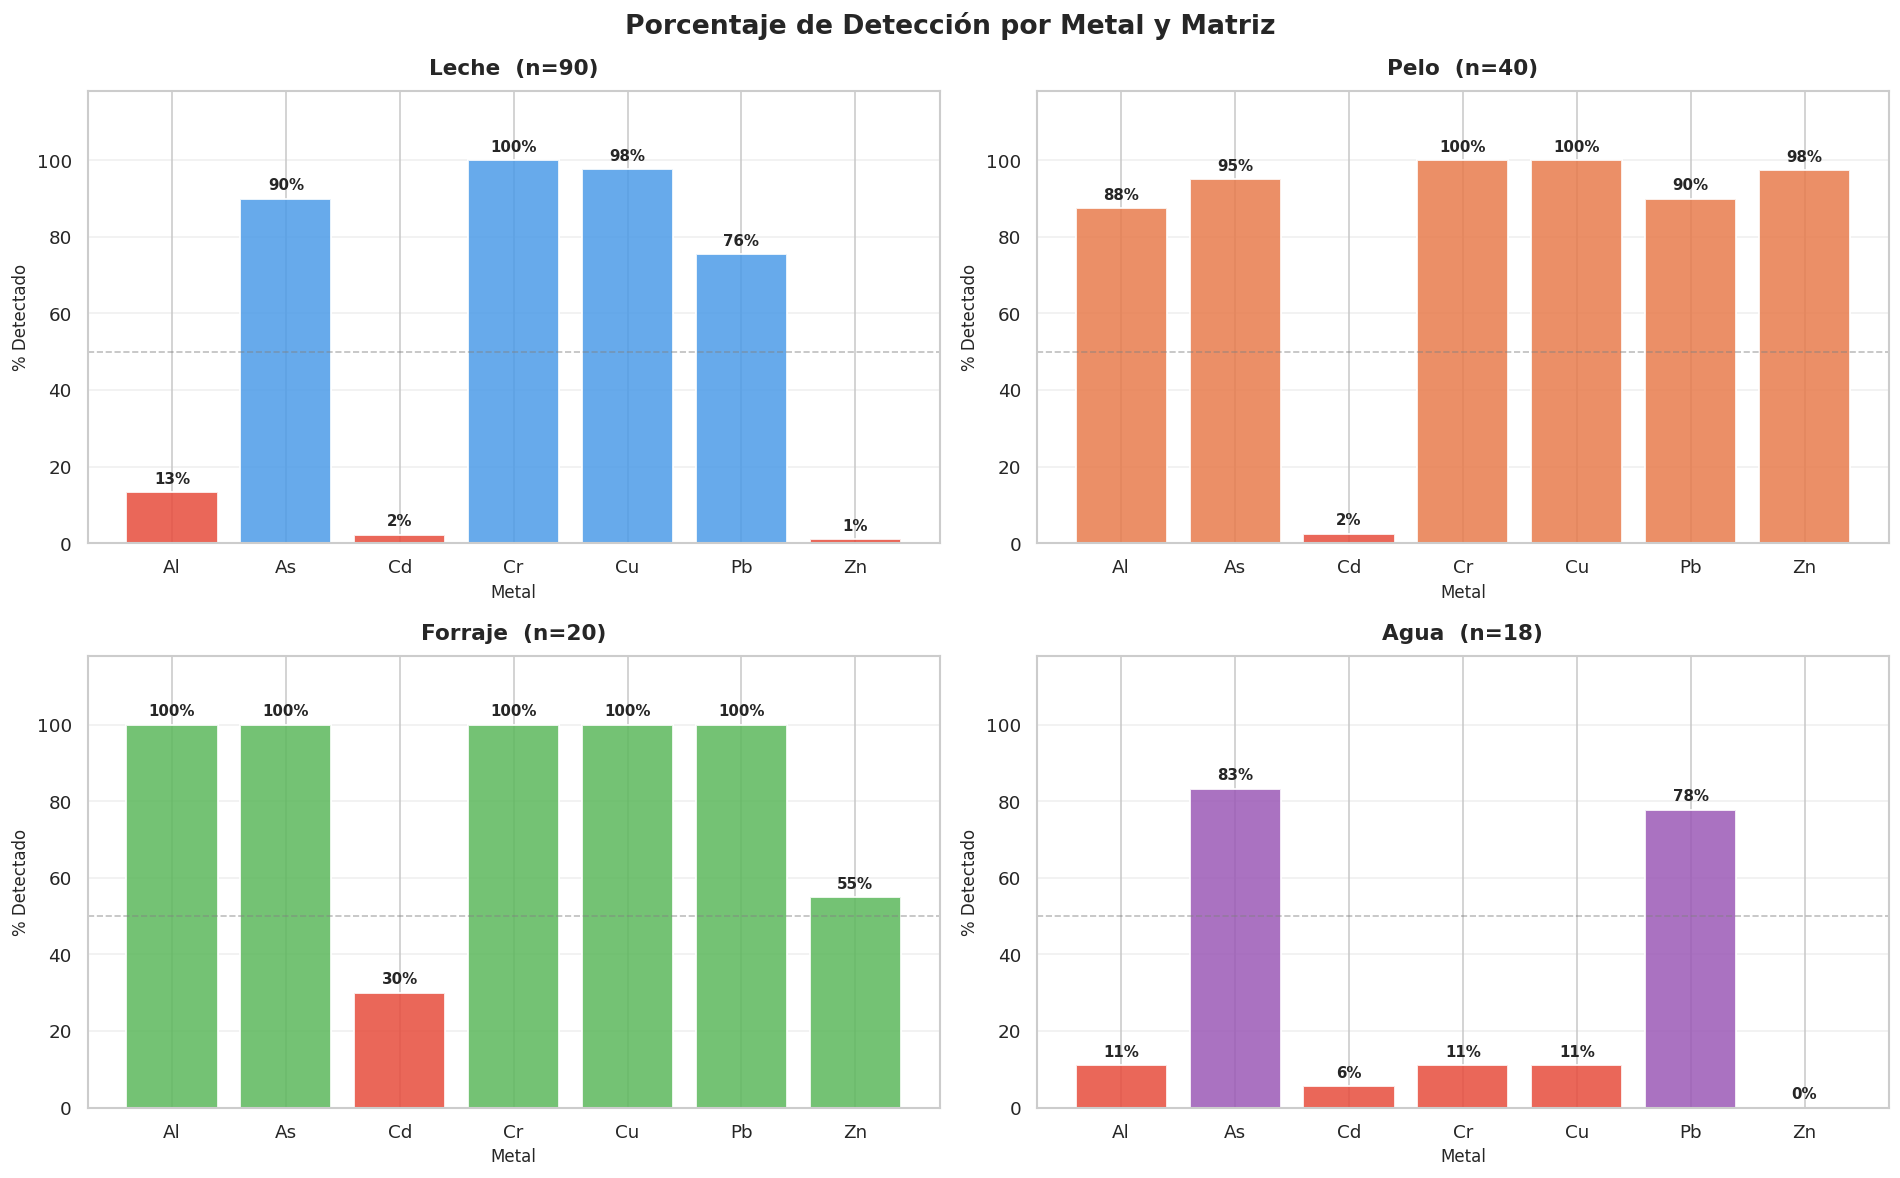

✅ Guardado: fig_deteccion_nd.png


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (nombre, df) in enumerate(dataframes.items()):
    ax   = axes[idx]
    mapa = {c: nombre_corto(c) for c in metales_por[nombre]}
    df_m = df[metales_por[nombre]].rename(columns=mapa)

    total    = len(df_m)
    det_pct  = df_m.notna().mean().mul(100)

    colors = [COLORES[nombre] if v >= 50 else '#E74C3C' for v in det_pct.values]
    bars   = ax.bar(det_pct.index, det_pct.values, color=colors,
                    edgecolor='white', linewidth=1.2, alpha=0.85)

    for bar, val in zip(bars, det_pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(f'{nombre}  (n={total})', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('% Detectado', fontsize=10)
    ax.set_ylim(0, 118)
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_xlabel('Metal', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Porcentaje de Detección por Metal y Matriz', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_PATH / 'fig_deteccion_nd.png', bbox_inches='tight')
plt.show()
print('✅ Guardado: fig_deteccion_nd.png')

## 4. Distribución de concentraciones por metal (Boxplots)

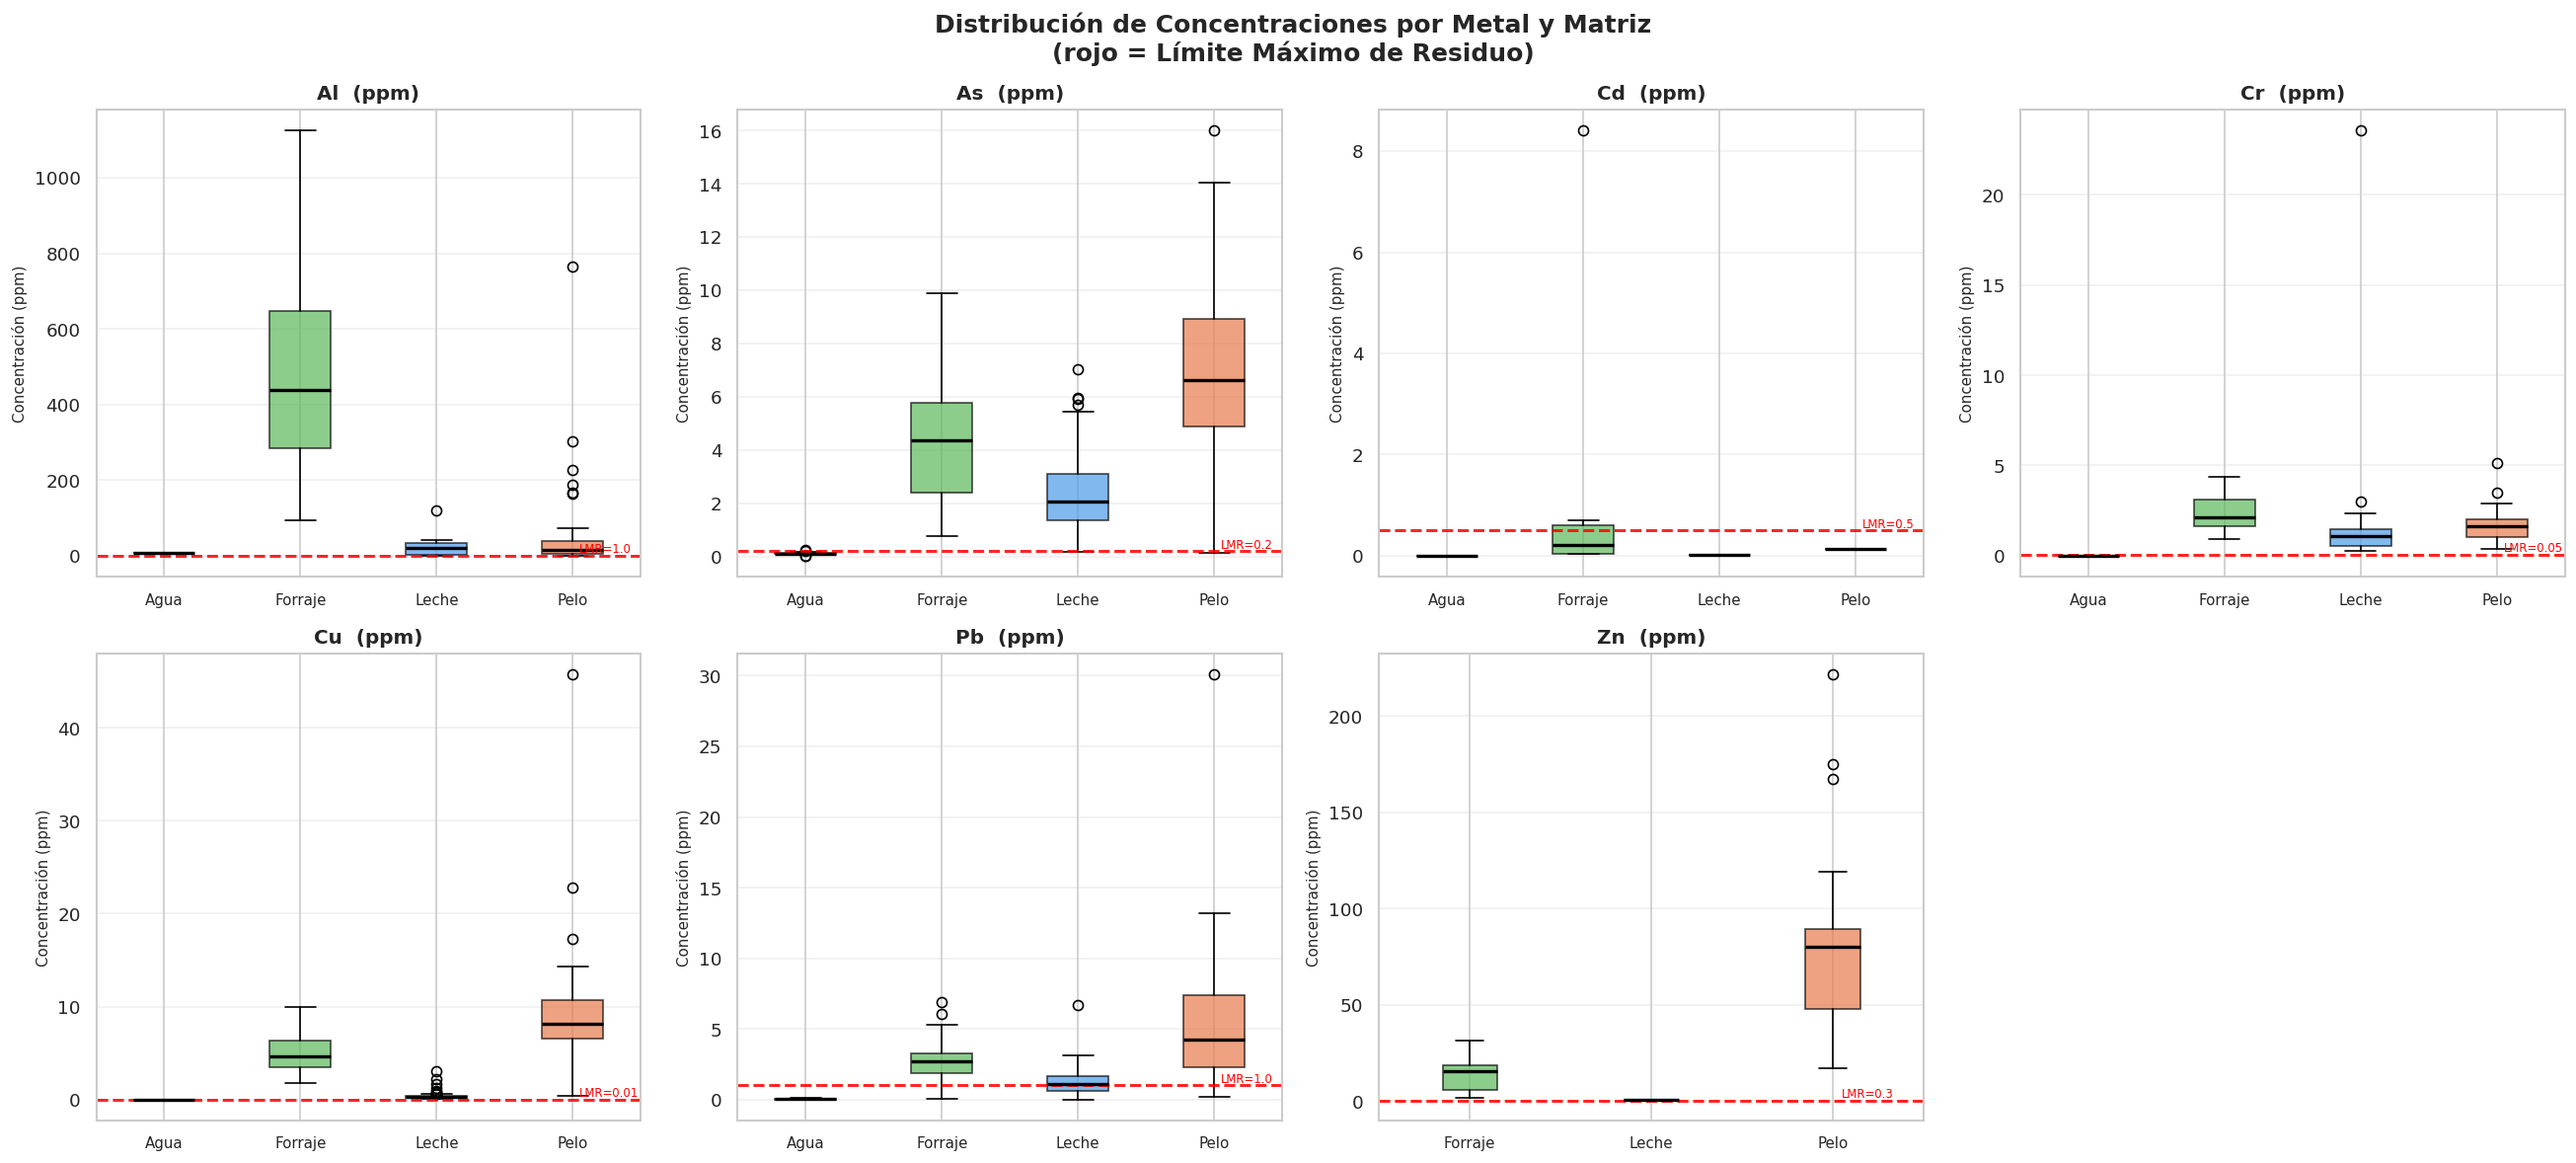

✅ Guardado: fig_boxplots_metales.png


In [30]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

orden = ['Agua', 'Forraje', 'Leche', 'Pelo']   # cadena alimentaria

for idx, metal in enumerate(METALES_COLS):
    ax = axes[idx]
    data_list, labels, colors = [], [], []

    for nombre in orden:
        if nombre not in dataframes:
            continue
        mapa = {c: nombre_corto(c) for c in metales_por[nombre]}
        df_m = dataframes[nombre][metales_por[nombre]].rename(columns=mapa)
        if metal in df_m.columns:
            vals = df_m[metal].dropna().values
            if len(vals):
                data_list.append(vals)
                labels.append(nombre)
                colors.append(COLORES[nombre])

    if data_list:
        bp = ax.boxplot(data_list, patch_artist=True, labels=labels,
                        medianprops=dict(color='black', linewidth=2))
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c); patch.set_alpha(0.7)

        if metal in LMR:
            ax.axhline(LMR[metal], color='red', linestyle='--', linewidth=1.8, alpha=0.85)
            ax.text(len(data_list) + 0.05, LMR[metal],
                    f'LMR={LMR[metal]}', fontsize=7, color='red', va='bottom')

    ax.set_title(f'{metal}  (ppm)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Concentración (ppm)', fontsize=9)
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(axis='y', alpha=0.3)

for i in range(len(METALES_COLS), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Distribución de Concentraciones por Metal y Matriz\n(rojo = Límite Máximo de Residuo)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_PATH / 'fig_boxplots_metales.png', bbox_inches='tight')
plt.show()
print('✅ Guardado: fig_boxplots_metales.png')

## 5. Excedencias del LMR — Heatmap

In [31]:
rows = []
for nombre, df in dataframes.items():
    mapa = {c: nombre_corto(c) for c in metales_por[nombre]}
    df_m = df[metales_por[nombre]].rename(columns=mapa)
    for metal, limite in LMR.items():
        if metal in df_m.columns:
            vals  = df_m[metal].dropna()
            n_det = len(vals)
            n_exc = int((vals > limite).sum())
            rows.append({
                'Matriz': nombre, 'Metal': metal,
                'N_detectadas': n_det,
                'N_excede': n_exc,
                'Pct_excede': round(n_exc/n_det*100, 1) if n_det else 0,
                'LMR': limite
            })

df_lmr   = pd.DataFrame(rows)
tab_exc  = df_lmr.pivot_table(values='Pct_excede', index='Matriz', columns='Metal', fill_value=0)

print('% de muestras (detectadas) que EXCEDEN el LMR:')
print(tab_exc.round(1).to_string())

% de muestras (detectadas) que EXCEDEN el LMR:
Metal       Al     As    Cd     Cr     Cu    Pb     Zn
Matriz                                                
Agua     100.0   13.3   0.0    0.0   50.0   0.0    0.0
Forraje  100.0  100.0  33.3  100.0  100.0  95.0  100.0
Leche     83.3   98.8   0.0  100.0  100.0  52.9  100.0
Pelo      97.1   97.4   0.0  100.0  100.0  97.2  100.0


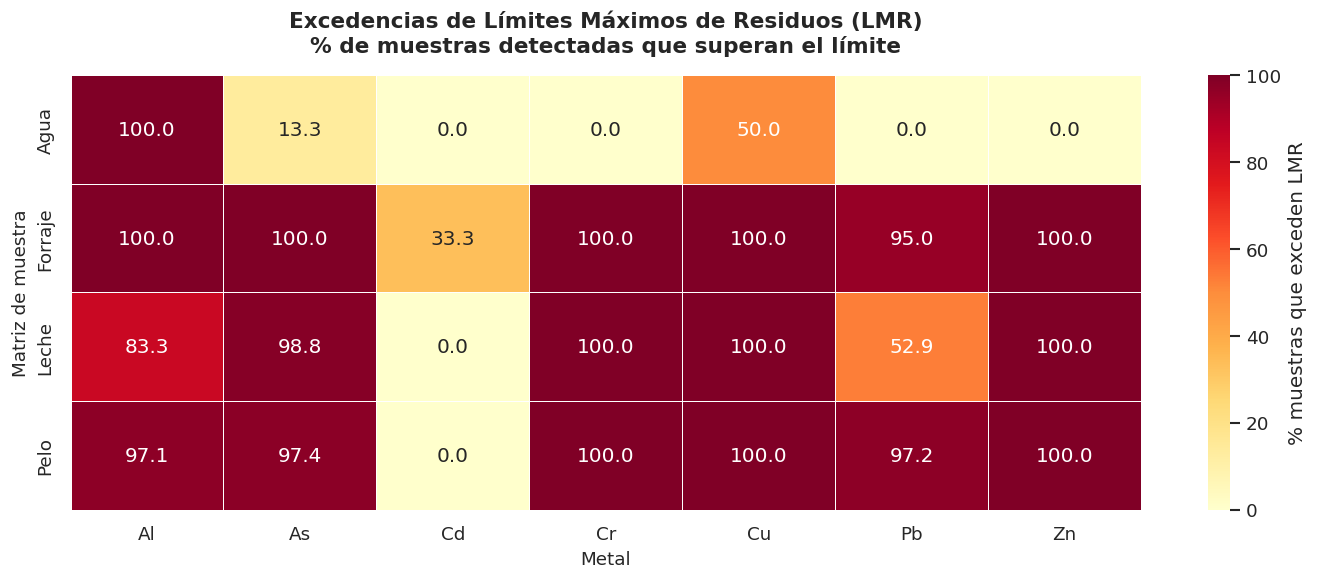

✅ Guardado: fig_heatmap_lmr.png


In [32]:
fig, ax = plt.subplots(figsize=(12, 5))

orden_mat = [m for m in ['Agua', 'Forraje', 'Leche', 'Pelo'] if m in tab_exc.index]
tab_plot  = tab_exc.loc[orden_mat]

sns.heatmap(tab_plot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': '% muestras que exceden LMR'},
            vmin=0, vmax=100)

ax.set_title('Excedencias de Límites Máximos de Residuos (LMR)\n% de muestras detectadas que superan el límite',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Metal', fontsize=11)
ax.set_ylabel('Matriz de muestra', fontsize=11)

plt.tight_layout()
plt.savefig(OUT_PATH / 'fig_heatmap_lmr.png', bbox_inches='tight')
plt.show()
print('✅ Guardado: fig_heatmap_lmr.png')

## 6. Análisis por ubicación geográfica

In [33]:
def municipio(lugar):
    if pd.isna(lugar): return 'Sin datos'
    l = str(lugar).lower()
    if 'lerma'      in l: return 'Lerma'
    if 'san mat'    in l: return 'San Mateo'
    if 'ocoyoacac'  in l: return 'Ocoyoacac'
    if 'chignahuap' in l or 'san agust' in l: return 'San Agustín'
    return lugar

df_all['Municipio'] = df_all['Lugar'].apply(municipio)

print('Muestras por Municipio y Matriz:')
print(df_all.groupby(['Municipio', 'Matriz']).size().unstack(fill_value=0).to_string())

Muestras por Municipio y Matriz:
Matriz       Agua  Forraje  Leche  Pelo
Municipio                              
Lerma           3        3      3     3
Ocoyoacac       2        2      2     1
San Agustín     1        1      1     1
San Mateo       3        4      3     3
Sin datos       9       10     81    32


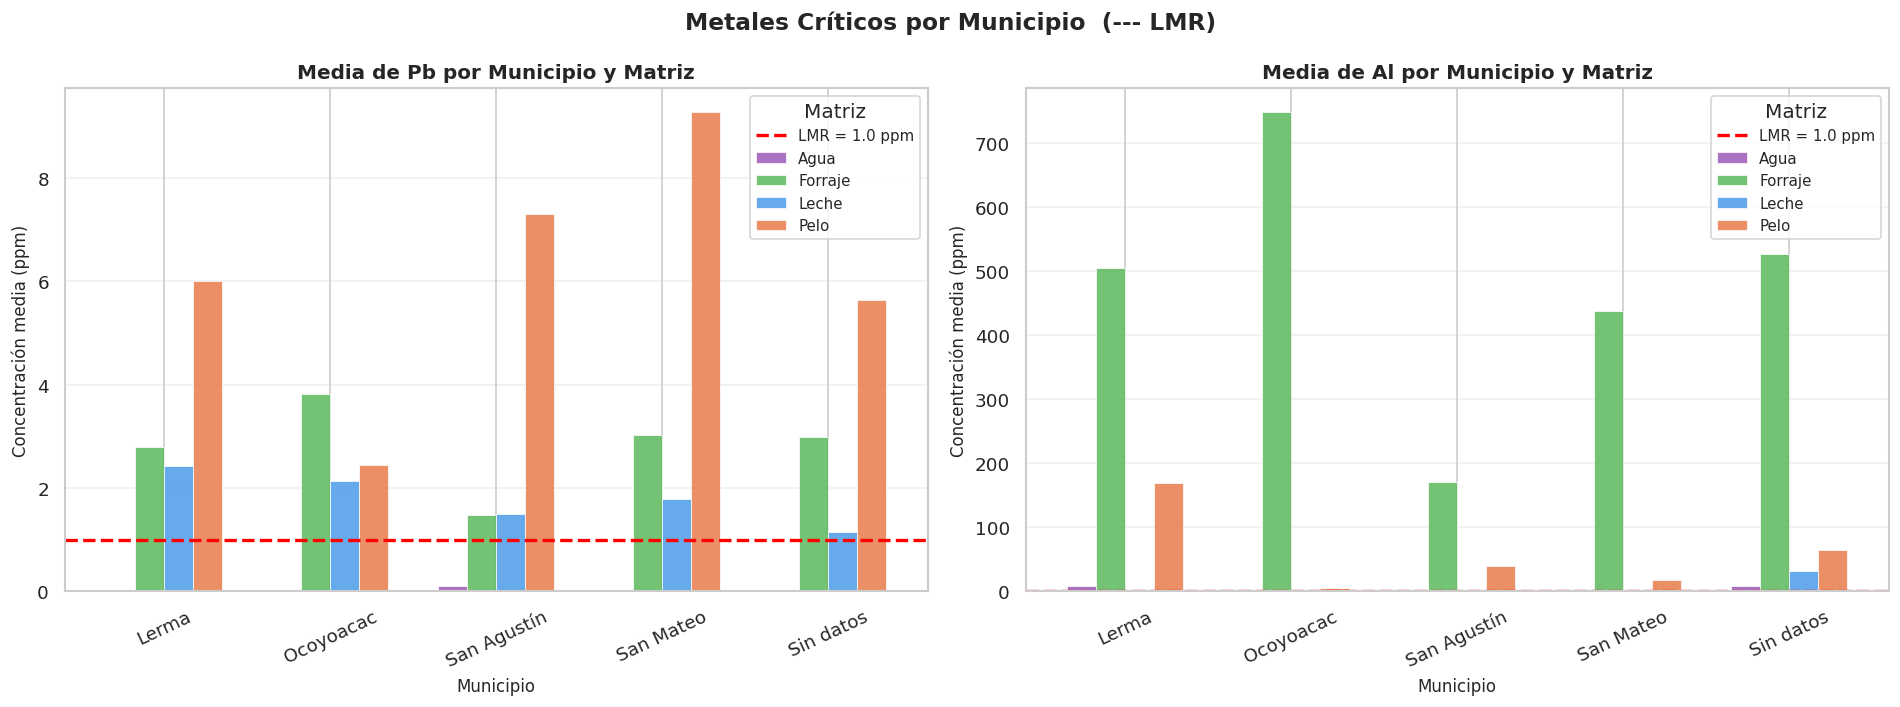

✅ Guardado: fig_pb_al_municipio.png


In [34]:
# Pb y Al son los metales más críticos según el artículo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metal in zip(axes, ['Pb', 'Al']):
    if metal not in df_all.columns:
        ax.text(0.5, 0.5, f'{metal} no disponible', ha='center', va='center',
                transform=ax.transAxes); continue

    pivot = (df_all[df_all[metal].notna()]
             .groupby(['Municipio', 'Matriz'])[metal].mean()
             .unstack(fill_value=np.nan))

    pivot.plot(kind='bar', ax=ax,
               color=[COLORES.get(c, 'gray') for c in pivot.columns],
               edgecolor='white', linewidth=0.5, alpha=0.85, width=0.7)

    if metal in LMR:
        ax.axhline(LMR[metal], color='red', linestyle='--', linewidth=2,
                   label=f'LMR = {LMR[metal]} ppm')

    ax.set_title(f'Media de {metal} por Municipio y Matriz', fontsize=12, fontweight='bold')
    ax.set_xlabel('Municipio', fontsize=10)
    ax.set_ylabel('Concentración media (ppm)', fontsize=10)
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Matriz', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Metales Críticos por Municipio  (--- LMR)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_PATH / 'fig_pb_al_municipio.png', bbox_inches='tight')
plt.show()
print('✅ Guardado: fig_pb_al_municipio.png')

## 7. Correlaciones entre metales (Spearman)

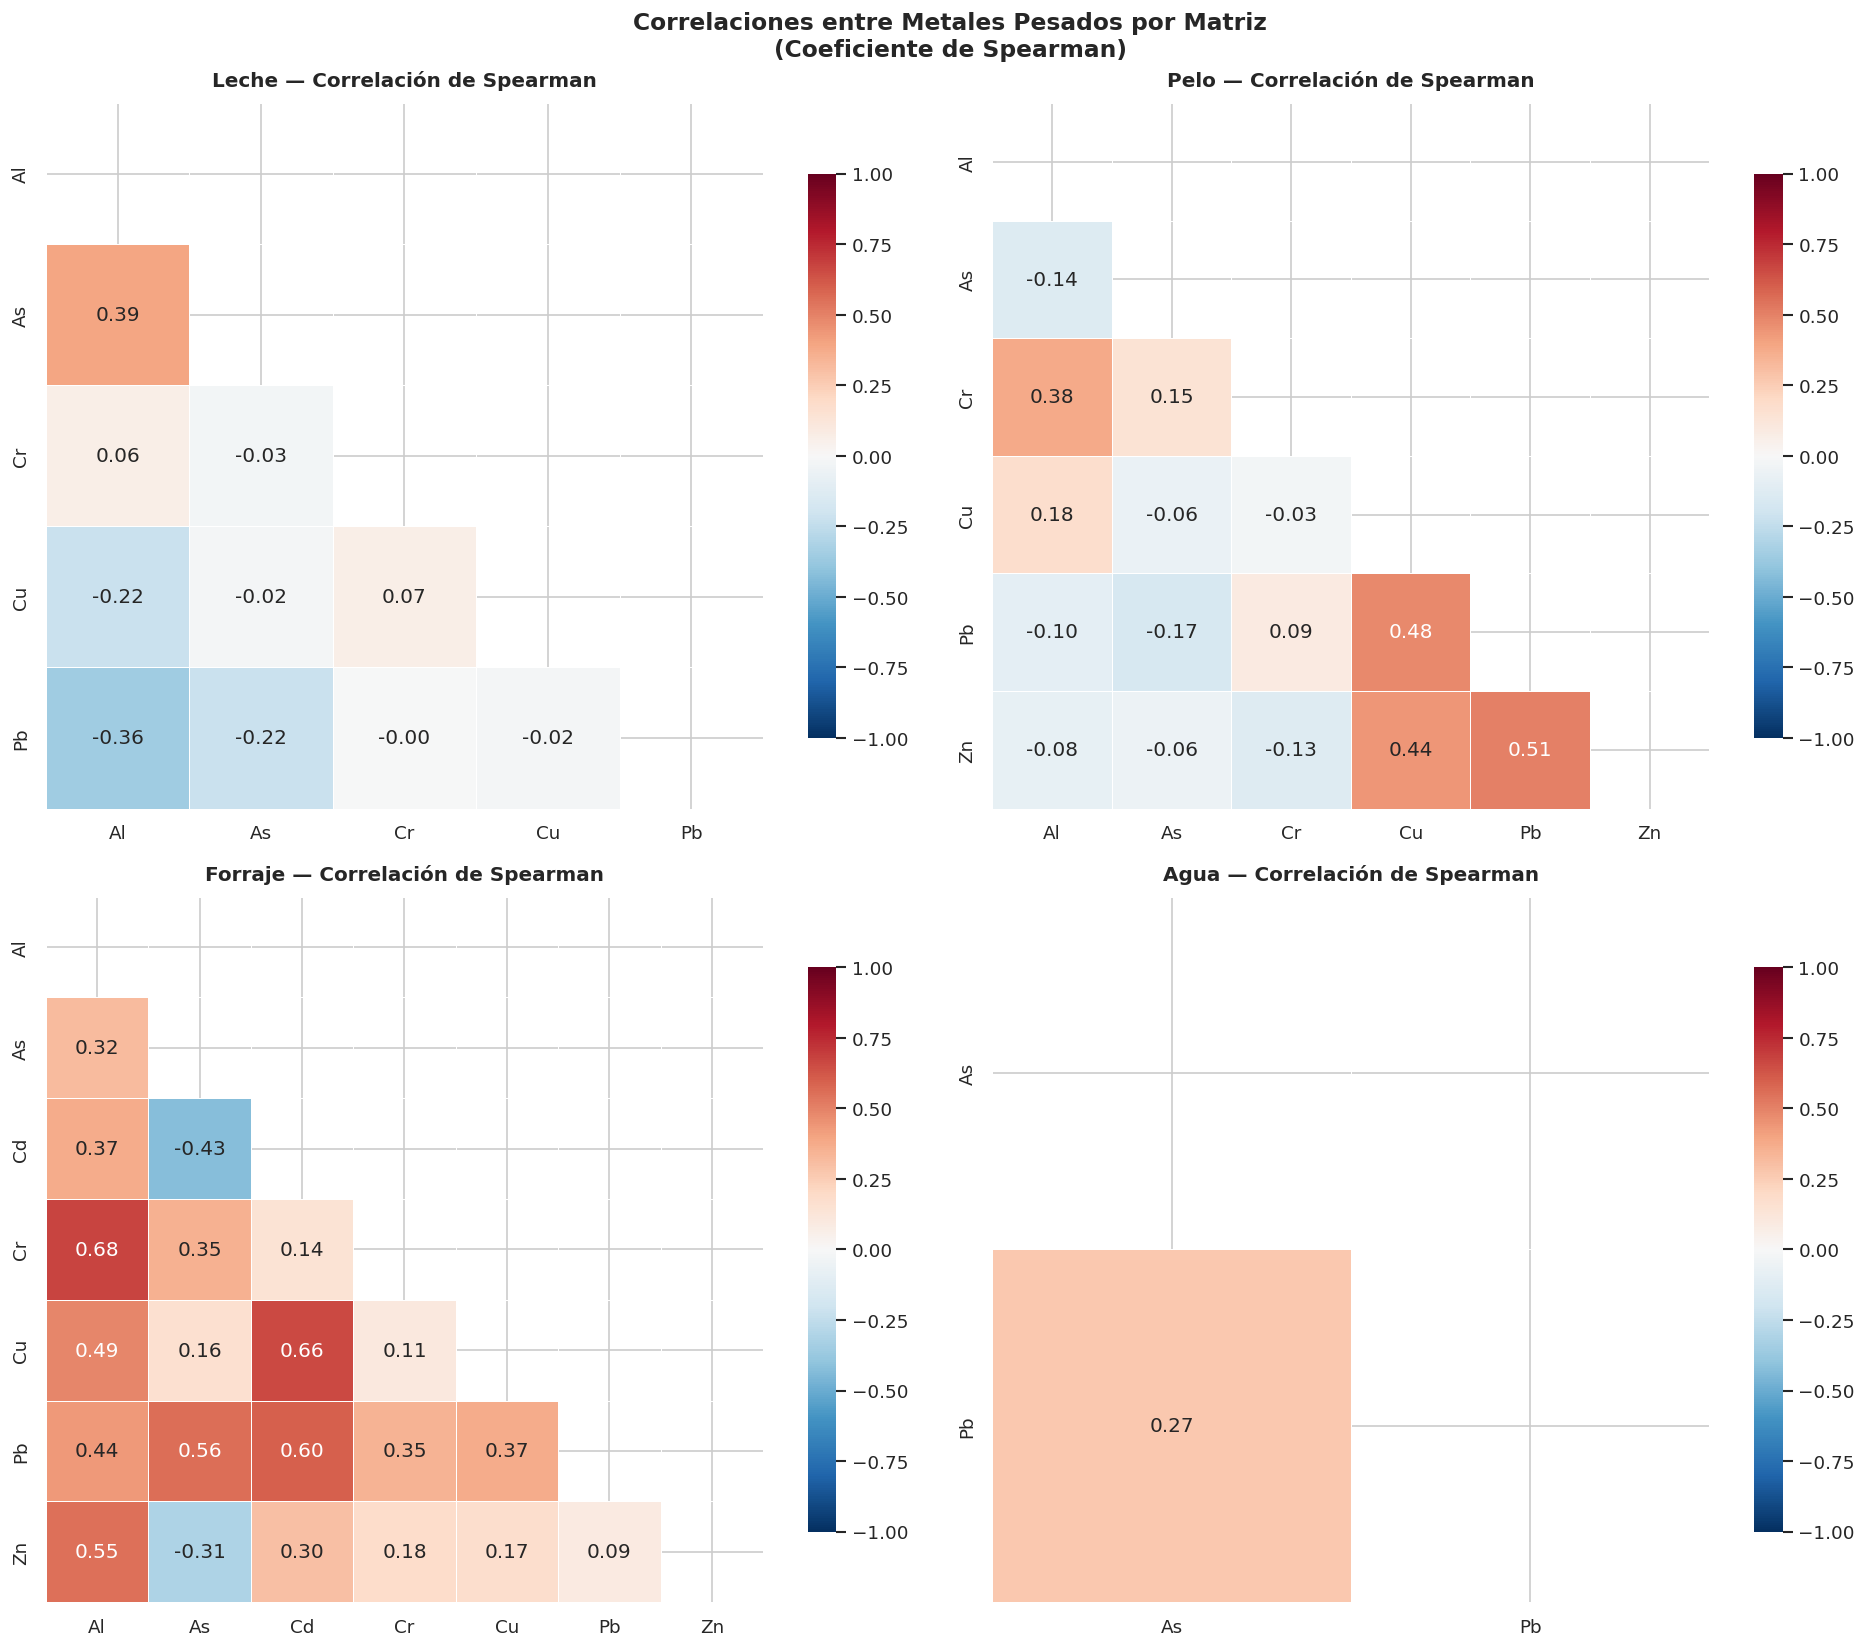

✅ Guardado: fig_correlaciones.png


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (nombre, df) in enumerate(dataframes.items()):
    ax   = axes[idx]
    mapa = {c: nombre_corto(c) for c in metales_por[nombre]}
    df_m = df[metales_por[nombre]].rename(columns=mapa)

    # Solo columnas con al menos 3 valores
    df_m = df_m[[c for c in df_m.columns if df_m[c].notna().sum() >= 3]]

    if df_m.shape[1] < 2:
        ax.text(0.5, 0.5, 'Datos insuficientes', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(nombre, fontsize=12, fontweight='bold')
        continue

    corr = df_m.corr(method='spearman')
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})

    ax.set_title(f'{nombre} — Correlación de Spearman', fontsize=12, fontweight='bold', pad=10)

plt.suptitle('Correlaciones entre Metales Pesados por Matriz\n(Coeficiente de Spearman)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_PATH / 'fig_correlaciones.png', bbox_inches='tight')
plt.show()
print('✅ Guardado: fig_correlaciones.png')

## 8. Perfil de bioacumulación en la cadena alimentaria

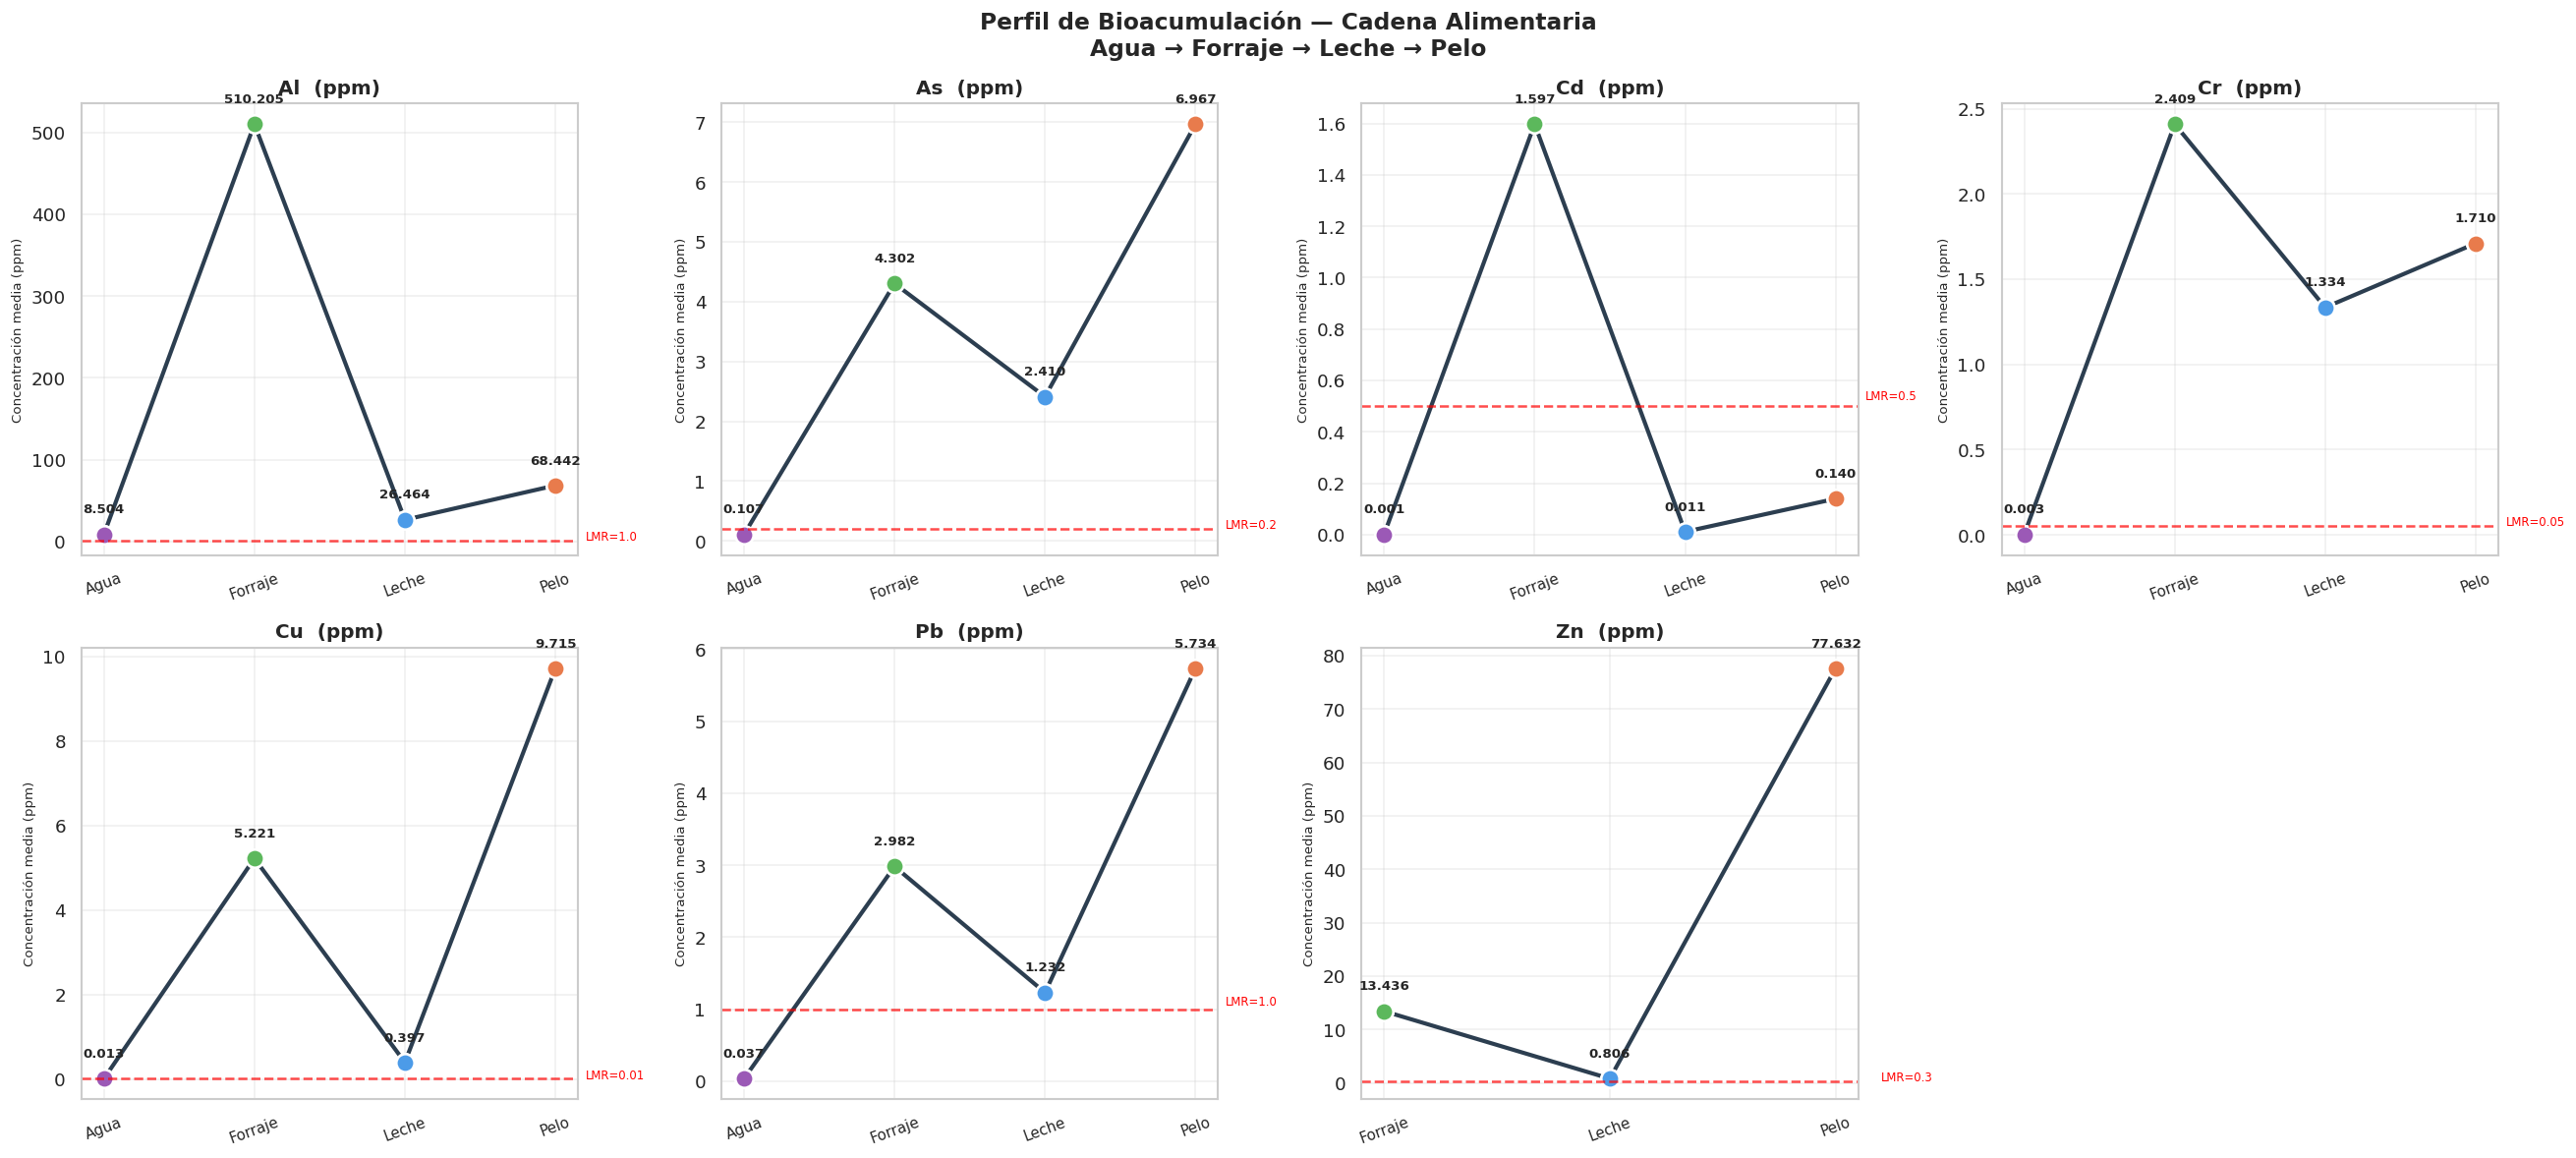

✅ Guardado: fig_bioacumulacion.png


In [36]:
orden_cadena = ['Agua', 'Forraje', 'Leche', 'Pelo']

medias_cadena = {}
for nombre in orden_cadena:
    if nombre in dataframes:
        mapa  = {c: nombre_corto(c) for c in metales_por[nombre]}
        df_m  = dataframes[nombre][metales_por[nombre]].rename(columns=mapa)
        medias_cadena[nombre] = df_m[METALES_COLS].mean()

df_cadena = pd.DataFrame(medias_cadena).T

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, metal in enumerate(METALES_COLS):
    ax   = axes[idx]

    if metal in df_cadena.columns:
        vals = df_cadena[metal].reindex(orden_cadena).dropna()

        ax.plot(range(len(vals)), vals.values,
                'o-', linewidth=2.5, markersize=11, color='#2C3E50',
                markeredgecolor='white', markeredgewidth=1.5)

        # Colorear cada punto según la matriz
        for xi, (lbl, val) in enumerate(zip(vals.index, vals.values)):
            ax.plot(xi, val, 'o', markersize=11,
                    color=COLORES[lbl], markeredgecolor='white', markeredgewidth=1.5)
            ax.annotate(f'{val:.3f}', (xi, val),
                        textcoords='offset points', xytext=(0, 13),
                        ha='center', fontsize=8, fontweight='bold')

        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(vals.index, rotation=20, fontsize=9)

        if metal in LMR:
            ax.axhline(LMR[metal], color='red', linestyle='--', linewidth=1.5, alpha=0.7)
            ax.text(len(vals) - 0.8, LMR[metal] * 1.05, f'LMR={LMR[metal]}',
                    fontsize=7, color='red')

    ax.set_title(f'{metal}  (ppm)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Concentración media (ppm)', fontsize=8)
    ax.grid(alpha=0.3)

for i in range(len(METALES_COLS), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Perfil de Bioacumulación — Cadena Alimentaria\nAgua → Forraje → Leche → Pelo',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_PATH / 'fig_bioacumulacion.png', bbox_inches='tight')
plt.show()
print('✅ Guardado: fig_bioacumulacion.png')

## 9. Histogramas + KDE — Leche (matriz de consumo humano)

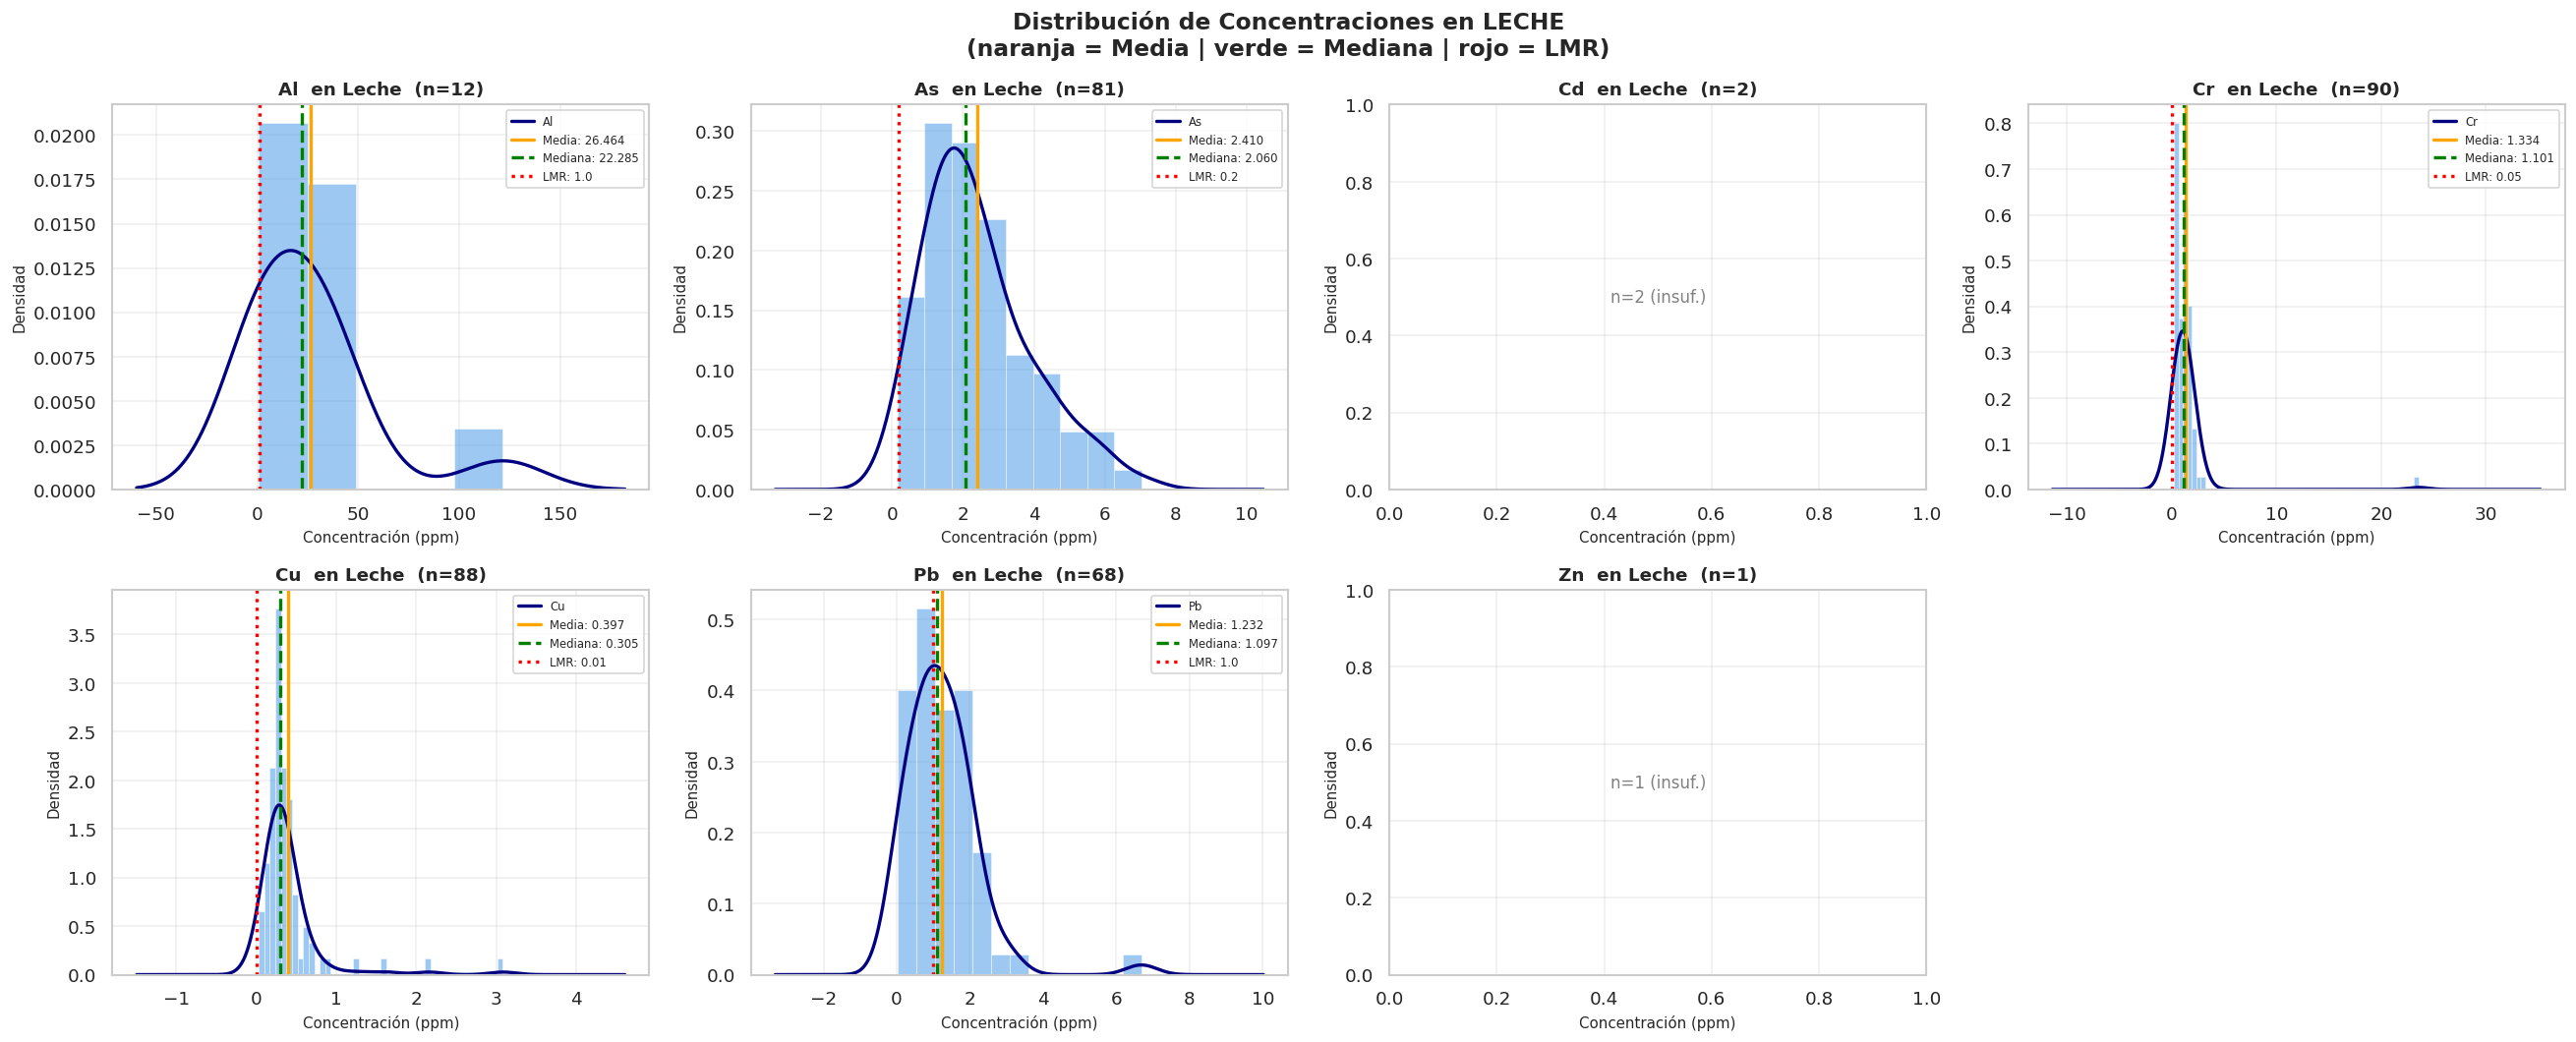

✅ Guardado: fig_hist_leche.png


In [37]:
mapa_l  = {c: nombre_corto(c) for c in metales_por['Leche']}
df_lm   = dataframes['Leche'][metales_por['Leche']].rename(columns=mapa_l)

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.flatten()

for idx, metal in enumerate(METALES_COLS):
    ax   = axes[idx]

    if metal not in df_lm.columns:
        ax.set_visible(False); continue

    data = df_lm[metal].dropna()

    if len(data) >= 3:
        ax.hist(data, bins='auto', color=COLORES['Leche'], alpha=0.55,
                density=True, edgecolor='white', linewidth=0.5)
        try:
            data.plot.kde(ax=ax, color='navy', linewidth=2)
        except Exception:
            pass

        ax.axvline(data.mean(),   color='orange', linewidth=2, label=f'Media: {data.mean():.3f}')
        ax.axvline(data.median(), color='green',  linewidth=2, linestyle='--',
                   label=f'Mediana: {data.median():.3f}')

        if metal in LMR:
            ax.axvline(LMR[metal], color='red', linewidth=2, linestyle=':',
                       label=f'LMR: {LMR[metal]}')

        ax.legend(fontsize=7, loc='upper right')
    else:
        ax.text(0.5, 0.5, f'n={len(data)} (insuf.)', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray')

    ax.set_title(f'{metal}  en Leche  (n={len(data)})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Concentración (ppm)', fontsize=9)
    ax.set_ylabel('Densidad', fontsize=9)
    ax.grid(alpha=0.3)

for i in range(len(METALES_COLS), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Distribución de Concentraciones en LECHE\n(naranja = Media | verde = Mediana | rojo = LMR)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_PATH / 'fig_hist_leche.png', bbox_inches='tight')
plt.show()
print('✅ Guardado: fig_hist_leche.png')

## 10. Tabla resumen y exportación a Excel

In [38]:
rows = []
for nombre, df in dataframes.items():
    mapa = {c: nombre_corto(c) for c in metales_por[nombre]}
    df_m = df[metales_por[nombre]].rename(columns=mapa)

    for metal in METALES_COLS:
        if metal not in df_m.columns:
            continue
        vals  = df_m[metal].dropna()
        n_tot = len(df_m)
        n_det = len(vals)
        lmr   = LMR.get(metal, np.nan)
        n_exc = int((vals > lmr).sum()) if n_det and not np.isnan(lmr) else 0

        rows.append({
            'Matriz':        nombre,
            'Metal':         metal,
            'LMR (ppm)':     lmr,
            'N_total':       n_tot,
            'N_detectadas':  n_det,
            '% Detectado':   round(n_det/n_tot*100, 1) if n_tot else 0,
            'Min':           round(vals.min(),    4) if n_det else np.nan,
            'Media':         round(vals.mean(),   4) if n_det else np.nan,
            'Mediana':       round(vals.median(), 4) if n_det else np.nan,
            'Max':           round(vals.max(),    4) if n_det else np.nan,
            'SD':            round(vals.std(),    4) if n_det > 1 else np.nan,
            'N_excede_LMR':  n_exc,
            '% excede_LMR':  round(n_exc/n_det*100, 1) if n_det else 0,
        })

df_res = pd.DataFrame(rows)

out_csv = OUT_PATH / 'resumen_EDA_metales.csv'
df_res.to_csv(out_csv, index=False, encoding='utf-8')
print(f'✅ CSV exportado → {out_csv}')
df_res

✅ CSV exportado → /home/jperez/ml-nutraceuticos-ganado-lechero/data/processed/eda_outputs/resumen_EDA_metales.csv


,Matriz,Metal,LMR (ppm),N_total,N_detectadas,% Detectado,Min,Media,Mediana,Max,SD,N_excede_LMR,% excede_LMR
0,Leche,Al,1.00,90,12,13.3,0.784,26.4643,22.2855,121.649,33.8571,10,83.3
1,Leche,As,0.20,90,81,90.0,0.150,2.4100,2.0600,7.030,1.4948,80,98.8
2,Leche,Cd,0.50,90,2,2.2,0.006,0.0115,0.0115,0.017,0.0078,0,0.0
3,Leche,Cr,0.05,90,90,100.0,0.246,1.3341,1.1005,23.557,2.4345,90,100.0
4,Leche,Cu,0.01,90,88,97.8,0.031,0.3970,0.3050,3.081,0.4174,88,100.0
5,Leche,Pb,1.00,90,68,75.6,0.016,1.2319,1.0970,6.685,0.9983,36,52.9
6,Leche,Zn,0.30,90,1,1.1,0.806,0.8060,0.8060,0.806,NaN,1,100.0
7,Pelo,Al,1.00,40,35,87.5,0.894,68.4424,16.3000,765.512,141.1776,34,97.1
8,Pelo,As,0.20,40,38,95.0,0.149,6.9669,6.6280,15.994,3.5667,37,97.4
9,Pelo,Cd,0.50,40,1,2.5,0.140,0.1400,0.1400,0.140,NaN,0,0.0


## 11. Resumen ejecutivo de hallazgos

In [39]:
print('=' * 70)
print('📋  RESUMEN EJECUTIVO — EDA Metales Pesados en Bovinos Lecheros')
print('=' * 70)
print(f"""
DATASET
  • Total muestras : {len(df_all)}
  • Matrices       : Leche (n=90), Pelo (n=40), Forraje (n=20), Agua (n=18)
  • Metales        : Al, As, Cd, Cr, Cu, Pb, Zn  [ppm]
  • Municipios     : Lerma, San Mateo, Ocoyoacac, San Agustín Chignahuapan
  • Método         : ICP-OES Varian 725-ES
""")

print('HALLAZGOS PRINCIPALES')
print('-' * 50)
for nombre, df in dataframes.items():
    mapa = {c: nombre_corto(c) for c in metales_por[nombre]}
    df_m = df[metales_por[nombre]].rename(columns=mapa)

    excedencias, nd_altos = [], []
    for metal, limite in LMR.items():
        if metal not in df_m.columns: continue
        vals   = df_m[metal].dropna()
        nd_pct = df_m[metal].isna().mean() * 100
        if len(vals) and (vals > limite).any():
            pct = (vals > limite).mean() * 100
            excedencias.append(f'{metal}: {pct:.0f}%  (máx={vals.max():.3f} ppm)')
        if nd_pct > 80:
            nd_altos.append(f'{metal}: {nd_pct:.0f}% ND')

    print(f'\n🔬 {nombre.upper()}:')
    print(f'   ⚠️  Exceden LMR : {", ".join(excedencias) if excedencias else "Ninguno"}')
    if nd_altos:
        print(f'   ℹ️  Alta tasa ND : {", ".join(nd_altos)}')

print(f"""

RECOMENDACIONES PARA ANÁLISIS FINAL
  1. Imputar ND con LOD/2 para análisis paramétrico.
  2. Aplicar Shapiro-Wilk para verificar normalidad por metal y matriz.
  3. Comparar municipios con ANOVA o Kruskal-Wallis.
  4. Evaluar correlaciones entre matrices (¿agua → leche → pelo?).
  5. Calcular Índice de Contaminación Total por ubicación.
  6. PCA para identificar patrones geográficos y perfiles de contaminación.
""")
print('=' * 70)

📋  RESUMEN EJECUTIVO — EDA Metales Pesados en Bovinos Lecheros

DATASET
  • Total muestras : 168
  • Matrices       : Leche (n=90), Pelo (n=40), Forraje (n=20), Agua (n=18)
  • Metales        : Al, As, Cd, Cr, Cu, Pb, Zn  [ppm]
  • Municipios     : Lerma, San Mateo, Ocoyoacac, San Agustín Chignahuapan
  • Método         : ICP-OES Varian 725-ES

HALLAZGOS PRINCIPALES
--------------------------------------------------

🔬 LECHE:
   ⚠️  Exceden LMR : Al: 83%  (máx=121.649 ppm), As: 99%  (máx=7.030 ppm), Cr: 100%  (máx=23.557 ppm), Cu: 100%  (máx=3.081 ppm), Pb: 53%  (máx=6.685 ppm), Zn: 100%  (máx=0.806 ppm)
   ℹ️  Alta tasa ND : Al: 87% ND, Cd: 98% ND, Zn: 99% ND

🔬 PELO:
   ⚠️  Exceden LMR : Al: 97%  (máx=765.512 ppm), As: 97%  (máx=15.994 ppm), Cr: 100%  (máx=5.131 ppm), Cu: 100%  (máx=45.730 ppm), Pb: 97%  (máx=30.086 ppm), Zn: 100%  (máx=221.593 ppm)
   ℹ️  Alta tasa ND : Cd: 98% ND

🔬 FORRAJE:
   ⚠️  Exceden LMR : Al: 100%  (máx=1124.420 ppm), As: 100%  (máx=9.891 ppm), Cd: 33%  (máx

In [40]:
import os
print('\n📁 Archivos generados en:', OUT_PATH)
for f in sorted(OUT_PATH.iterdir()):
    print(f'   {f.name:<55s}  {f.stat().st_size/1024:6.1f} KB')


📁 Archivos generados en: /home/jperez/ml-nutraceuticos-ganado-lechero/data/processed/eda_outputs
   fig_bioacumulacion.png                                    227.4 KB
   fig_boxplots_metales.png                                  115.0 KB
   fig_correlaciones.png                                     148.3 KB
   fig_deteccion_nd.png                                       83.9 KB
   fig_heatmap_lmr.png                                        62.1 KB
   fig_hist_leche.png                                        205.9 KB
   fig_pb_al_municipio.png                                    73.5 KB
   resumen_EDA_metales.csv                                     1.8 KB
